In [14]:
import networkx as nx
import os
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
sns.set_theme()
sns.set_style("whitegrid", {'grid.color': 'black', 'axes.edgecolor': 'black', 'axes.axisbelow': 'line'})
sns.set_style({'font.family': 'serif'})
sns.set_style({'font.serif': ["Linux Libertine O"]})


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Linux Libertine O"],
    "font.cursive": ["Linux Libertine O"], 
    "font.sans-serif": ["Linux Libertine O"],
    
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    
    "mathtext.fontset": "custom",
    "mathtext.rm": "Linux Libertine O",
    "mathtext.it": "Linux Libertine O:italic",
    "mathtext.bf": "Linux Libertine O:bold",
    "mathtext.sf": "Linux Libertine O",
})

In [16]:
all_node_labels = ['F-node', 'UEs', 'a1_latency_mean_dl_ms', 'a1_latency_mean_ul_ms',
       'a1_latency_p90_dl_ms', 'a1_latency_p90_ul_ms',
       'a1_packet_loss_dl_percentage', 'a1_packet_loss_ul_percentage',
       'a1_retransmissions_dl_count', 'a1_retransmissions_ul_count',
       'a1_throughput_dl_kbps', 'a1_throughput_ul_kbps',
       'e2_du_latency_mean_dl_ms', 'e2_du_latency_mean_ul_ms',
       'e2_du_latency_p90_dl_ms', 'e2_du_latency_p90_ul_ms',
       'e2_du_packet_loss_dl_percentage', 'e2_du_packet_loss_ul_percentage',
       'e2_du_retransmissions_dl_count', 'e2_du_retransmissions_ul_count',
       'e2_du_throughput_dl_kbps', 'e2_du_throughput_ul_kbps',
       'f1_c_latency_mean_dl_ms', 'f1_c_latency_mean_ul_ms',
       'f1_c_latency_p90_dl_ms', 'f1_c_latency_p90_ul_ms',
       'f1_c_packet_loss_dl_percentage', 'f1_c_packet_loss_ul_percentage',
       'f1_c_retransmissions_dl_count', 'f1_c_retransmissions_ul_count',
       'f1_c_throughput_dl_kbps', 'f1_c_throughput_ul_kbps',
       'f1_u_latency_mean_dl_ms', 'f1_u_latency_mean_ul_ms',
       'f1_u_latency_p90_dl_ms', 'f1_u_latency_p90_ul_ms',
       'f1_u_packet_loss_dl_percentage', 'f1_u_packet_loss_ul_percentage',
       'f1_u_retransmissions_dl_count', 'f1_u_retransmissions_ul_count',
       'f1_u_throughput_dl_kbps', 'f1_u_throughput_ul_kbps']

In [17]:
import math
def penalization(s, p, hyper_lambda=0.5):
    """
    s: input score
    p: probability or penalty factor
    hyper_lambda: scalar to tune penalization strength (default 1.0)
    """
    
    penalty_term = hyper_lambda * (1 - p)
    v = s * (1 + penalty_term)
    v  = max(0, v)  # Ensure non-negativity
    v = min(v, 1)  # Cap at 1
    
    return v

def _weighted_graph_to_ordered_root_causes(weighted_graph_model, experiment_id, root_node='F-node', filepath=""):
        
        pred_distances = nx.shortest_path_length(
            weighted_graph_model, 
            source=root_node, 
            weight=lambda u, v, d: 1 - d.get("weight", 0)
        )
        pred_distances = {k: v for k, v in pred_distances.items() if k != root_node}
        

        # Save to file
        if filepath:
            os.makedirs(os.path.dirname(filepath), exist_ok=True)
            with open(filepath, 'w') as f:
                for root_cause, distance in pred_distances.items():
                    f.write(f"{root_cause}\t{distance}\n")
                
        return pred_distances, list(pred_distances.keys())

def _weighted_graph_to_ordered_root_causes_confounder_penalty(weighted_graph_model, experiment_id, filepath=""):
        
    pred_distances, _ = _weighted_graph_to_ordered_root_causes(weighted_graph_model, experiment_id, root_node='F-node')
    
    pred_distances_ues, _ = _weighted_graph_to_ordered_root_causes(weighted_graph_model, experiment_id, root_node='UEs')
    
    # Penalization
    missing_keys = set(pred_distances) - set(pred_distances_ues)
    if missing_keys:
        raise KeyError(f"Missing keys in pred_distances_ues: {sorted(missing_keys)}")

    pred_distances_multiplied = {
        k: penalization(pred_distances[k], pred_distances_ues[k])
        for k in pred_distances
    }
    
    # sort dict
    pred_distances_multiplied = dict(sorted(pred_distances_multiplied.items(), key=lambda item: item[1]))

    # Save to file
    if filepath:
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        with open(filepath, 'w') as f:
            for root_cause, distance in pred_distances.items():
                f.write(f"{root_cause}\t{distance}\n")
            
    return pred_distances_multiplied, list(pred_distances_multiplied.keys())

In [18]:
base_path = './data/sam_outputs'
experiment = "pkt_loss_low-e2_upstream"
print(f"Processing {experiment}...")
weighted_graph_model_path = join(base_path, experiment, 'version_0', 'causal_graph_SAM.npy')
arr = np.load(weighted_graph_model_path, allow_pickle=True)

graph = nx.from_numpy_array(arr, create_using=nx.DiGraph)
mapping = {i: node for i, node in enumerate(all_node_labels)}
graph = nx.relabel_nodes(graph, mapping)


output_filepath = None

pred_distances, predicted_ordered_root_causes = _weighted_graph_to_ordered_root_causes(graph, experiment_id=experiment)
pred_distances_ues, predicted_ordered_root_causes_ues = _weighted_graph_to_ordered_root_causes(graph, experiment_id=experiment, root_node='UEs')

pred_distances_penalized, predicted_ordered_root_causes_penalized = _weighted_graph_to_ordered_root_causes_confounder_penalty(graph, experiment_id=experiment, filepath=output_filepath)

Processing pkt_loss_low-e2_upstream...


In [19]:
base_path = './data/sam_outputs'
experiment = "pkt_delay_low-e2_upstream"
print(f"Processing {experiment}...")
weighted_graph_model_path = join(base_path, experiment, 'version_0', 'causal_graph_SAM.npy')
arr = np.load(weighted_graph_model_path, allow_pickle=True)


thr = 0.5
arr_thresholded = arr > thr
graph = nx.from_numpy_array(arr_thresholded, create_using=nx.DiGraph)
mapping = {i: node for i, node in enumerate(all_node_labels)}
graph = nx.relabel_nodes(graph, mapping)

Processing pkt_delay_low-e2_upstream...


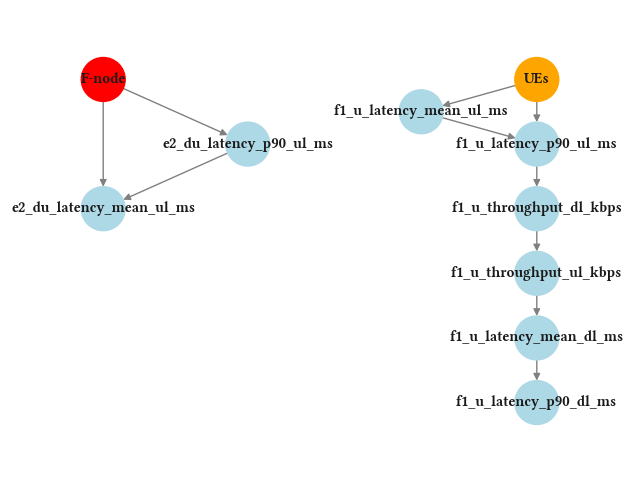

In [20]:
import matplotlib.pyplot as plt
import networkx as nx

targets = {"F-node", "UEs"}
nodes_to_keep = set()
for component in nx.weakly_connected_components(graph):
    if not targets.isdisjoint(component):
        nodes_to_keep.update(component)
subgraph = graph.subgraph(nodes_to_keep).copy()

manual_pos = {
    "F-node": (0, 2),
    "e2_du_latency_p90_ul_ms": (0.5, 1),
    "lu_latency_mean_ul_ms": (0, 0),

    "UEs": (1.5, 2),
    "f1_u_latency_mean_ul_ms": (1.1, 1.5),
    "f1_u_latency_p90_ul_ms": (1.5, 1),
    "f1_u_throughput_dl_kbps": (1.5, 0),
    "f1_u_throughput_ul_kbps": (1.5, -1),
    "f1_u_latency_mean_dl_ms": (1.5, -2),
    "f1_u_latency_p90_dl_ms": (1.5, -3),
}

pos = {node: manual_pos.get(node, (0, 0)) for node in subgraph.nodes()}

colors = []
for n in subgraph.nodes():
    if n == "F-node": colors.append("red")
    elif n == "UEs": colors.append("orange")
    else: colors.append("lightblue")

plt.figure(figsize=(8, 6))

nx.draw_networkx(
    subgraph, 
    pos, 
    font_size=10.5, 
    font_family="serif",
    font_weight='bold',
    node_size=1000, 
    node_color=colors, 
    edge_color='gray', 
    arrows=True,
)

plt.margins(0.15)
plt.axis('off')
plt.savefig(join('./plot_outputs', f"{experiment}_causal_graph.pdf"), bbox_inches='tight')
plt.show()

In [21]:
base_path = './data/sam_outputs'
experiment = "pkt_loss_low-e2_upstream"
print(f"Processing {experiment}...")
weighted_graph_model_path = join(base_path, experiment, 'version_0', 'causal_graph_SAM.npy')
arr = np.load(weighted_graph_model_path, allow_pickle=True)

graph = nx.from_numpy_array(arr, create_using=nx.DiGraph)
mapping = {i: node for i, node in enumerate(all_node_labels)}
graph = nx.relabel_nodes(graph, mapping)


output_filepath = None

pred_distances, predicted_ordered_root_causes = _weighted_graph_to_ordered_root_causes(graph, experiment_id=experiment)
pred_distances_ues, predicted_ordered_root_causes_ues = _weighted_graph_to_ordered_root_causes(graph, experiment_id=experiment, root_node='UEs')

pred_distances_penalized, predicted_ordered_root_causes_penalized = _weighted_graph_to_ordered_root_causes_confounder_penalty(graph, experiment_id=experiment, filepath=output_filepath)

Processing pkt_loss_low-e2_upstream...


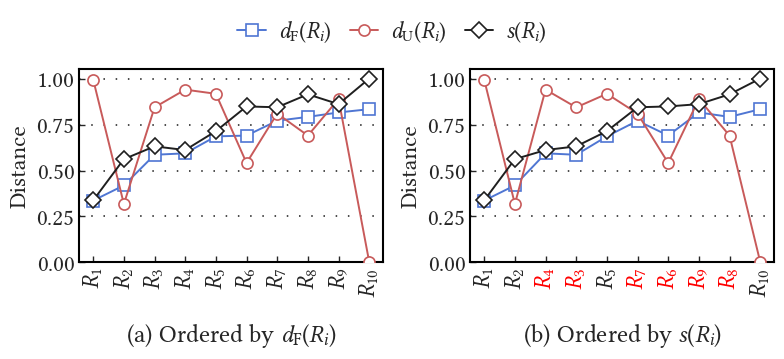

In [22]:
import matplotlib.pyplot as plt
import numpy as np


keys = list(pred_distances.keys())[:10]

y1 = np.array([pred_distances[k] for k in keys])
y2 = np.array([pred_distances_ues[k] for k in keys])
y3 = np.array([pred_distances_penalized[k] for k in keys])
y3[y3 > 1] = 1

x = np.arange(len(keys))

anonymized_keys = [rf'$R_{{{i+1}}}$' for i in range(len(keys))]

sort_indices = np.argsort(y3)
y1_sorted = y1[sort_indices]
y2_sorted = y2[sort_indices]
y3_sorted = y3[sort_indices]
keys_sorted = [anonymized_keys[i] for i in sort_indices]

color_blue = '#4F76D3'
color_red = '#C85A5A'
color_black = '#1F1F1F'
face_gray = "#FFFFFF"

def plot_and_style(ax, x_vals, y1_vals, y2_vals, y3_vals, x_labels):
    ax.set_facecolor(face_gray)
    
    ax.plot(x_vals, y1_vals, color=color_blue, linewidth=1.4, marker='s', markersize=8,
            markerfacecolor=face_gray, markeredgecolor=color_blue, markeredgewidth=1.2,
            label=r'$d_{\mathcal{F}}(R_i)$', zorder=3)
    ax.plot(x_vals, y2_vals, color=color_red, linewidth=1.4, marker='o', markersize=8,
            markerfacecolor=face_gray, markeredgecolor=color_red, markeredgewidth=1.2,
            label=r'$d_{\mathcal{U}}(R_i)$', zorder=3)
    ax.plot(x_vals, y3_vals, color=color_black, linewidth=1.4, marker='D', markersize=8,
            markerfacecolor=face_gray, markeredgecolor=color_black, markeredgewidth=1.2,
            label=r'$s(R_i)$', zorder=3)

    ax.set_ylabel('Distance', fontsize=17)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=17)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.25))
    ax.tick_params(axis='y', labelsize=17)
    ax.tick_params(bottom=True, left=True, direction='in', width=1.0, length=4)

    ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.9)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
fig.patch.set_facecolor(face_gray)

plot_and_style(ax1, x, y1, y2, y3, anonymized_keys)
ax1.set_title(r"(a) Ordered by $d_{\mathcal{F}}(R_i)$", y=-0.45, fontsize=18)

plot_and_style(ax2, x, y1_sorted, y2_sorted, y3_sorted, keys_sorted)
ax2.set_title(r"(b) Ordered by $s(R_i)$", y=-0.45, fontsize=18)

for j, tick_label in enumerate(ax2.get_xticklabels()):
    if sort_indices[j] != j:
        tick_label.set_color('red')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=17,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=0.8,
    borderaxespad=0.0
)

plt.tight_layout()
plt.savefig(join('./plot_outputs', 'scoring_functions_side_by_side_libertine.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Tool 1 plots

In [23]:
root_causes_eval = pd.read_csv('./data/sam_outputs/root_causes_eval.csv')
root_causes_metrics = ['ac_at_top_1', 'ac_at_top_3', 'ac_at_top_5']
root_causes_eval

,interface,experiment_type,experiment_strength,ac_at_top_1,ac_at_top_3,ac_at_top_5
0,a1_downstream,pkt_delay,high,1.0,1.0,1.0
1,a1_downstream,pkt_delay,low,1.0,1.0,1.0
2,a1_downstream,pkt_delay,medium,1.0,1.0,1.0
3,a1_downstream,pkt_loss,100,1.0,1.0,1.0
4,a1_downstream,pkt_loss,high,1.0,1.0,1.0
5,a1_downstream,pkt_loss,low,1.0,1.0,1.0
6,a1_downstream,pkt_loss,medium,1.0,1.0,1.0
7,e2_upstream,pkt_delay,high,0.0,0.0,0.0
8,e2_upstream,pkt_delay,low,1.0,1.0,1.0
9,e2_upstream,pkt_delay,medium,1.0,1.0,1.0


In [24]:
# Taking data from preprocesses CSV to avoid re-running the scoring methods every time.
root_causes_eval = root_causes_eval.groupby(['interface', 'experiment_type', 'experiment_strength']).mean()

In [25]:
def get_ac_vs_k(interface, experiment_type):
    vals = []
    for k_col in root_causes_metrics:
        df_sub = root_causes_eval.loc[(interface, experiment_type)]
        vals.append(df_sub[k_col].mean())
    return vals

strength_order = ['low', 'medium', 'high', '100']

def get_ac_vs_strength(interface, experiment_type):
    vals = []
    for s in strength_order:
        try:
            vals.append(root_causes_eval.loc[(interface, experiment_type, s)]['ac_at_top_3'])
        except KeyError:
            vals.append(np.nan)
    return vals

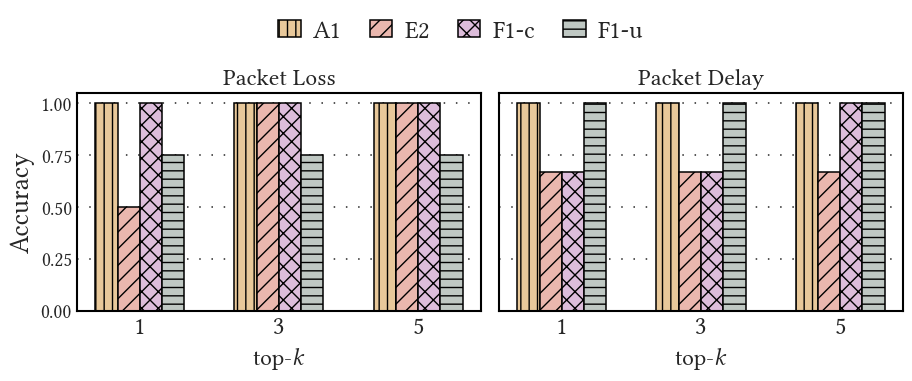

In [26]:
import matplotlib.pyplot as plt
import numpy as np

interfaces = ['a1_downstream', 'e2_upstream', 'f1-c_dl', 'f1-u_dl']
ks = [1, 3, 5]
ac_col_names = ['ac_at_top_1', 'ac_at_top_3', 'ac_at_top_5']

anomaly_strengths_loss = ['low', 'medium', 'high', '100']
anomaly_strengths_delay = ['low', 'medium', 'high']

interfaces_label_map = {
    'a1_downstream': 'A1',
    'e2_upstream': 'E2',
    'f1-c_dl': 'F1-c',
    'f1-u_dl': 'F1-u'
}

anomaly_strengths_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
    '100': 'Link Down'
}

anomaly_strengths_delay_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
}

anomaly_strengths_labels = [anomaly_strengths_label_map.get(s, s) for s in anomaly_strengths_loss]
anomaly_strengths_delay_labels = [anomaly_strengths_delay_label_map.get(s, s) for s in anomaly_strengths_delay]
legend_labels = [interfaces_label_map[interface] for interface in interfaces]

n_bars = len(interfaces)
bar_width = 0.16
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_width

panel_gray = "#FFFFFF"
series_colors = ['#E8C89A', '#EAB7AE', '#DDBDDB', '#BFC8C3']
series_hatches = ['||', '//', 'xx', '--']

def style_axes_like_reference(ax):
    ax.set_facecolor(panel_gray)
    ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig1, axs1 = plt.subplots(1, 2, figsize=(9.2, 3.7), sharey=True)
fig1.patch.set_facecolor(panel_gray)
x_indices = np.arange(len(ks))

for i, interface in enumerate(interfaces):
    vals_loss = get_ac_vs_k(interface, 'pkt_loss')
    x_pos = x_indices + offsets[i]
    axs1[0].bar(
        x_pos, vals_loss, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

for i, interface in enumerate(interfaces):
    vals_delay = get_ac_vs_k(interface, 'pkt_delay')
    x_pos = x_indices + offsets[i]
    axs1[1].bar(
        x_pos, vals_delay, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

style_axes_like_reference(axs1[0])
style_axes_like_reference(axs1[1])

axs1[0].set_title('Packet Loss', fontsize=17)
axs1[0].set_xlabel(r'top-$k$', fontsize=17)
axs1[0].set_ylabel('Accuracy', fontsize=19)
axs1[0].set_xticks(x_indices)
axs1[0].set_xticklabels(ks, fontsize=18)

axs1[1].set_title('Packet Delay', fontsize=17)
axs1[1].set_xlabel(r'top-$k$', fontsize=17)
axs1[1].set_xticks(x_indices)
axs1[1].set_xticklabels(ks, fontsize=18)

handles, labels = axs1[0].get_legend_handles_labels()
fig1.legend(
    handles, labels, loc='upper center', ncol=len(interfaces),
    bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=18,
    handlelength=0.9, handletextpad=0.5, columnspacing=1.1
)

plt.tight_layout()
plt.subplots_adjust(top=0.80)
plt.savefig('plot_outputs/causal_graph_evaluation_root_causes_ac_bar_plots_k_newstyle.pdf', bbox_inches='tight')
plt.show()

